# Lab 4: Linear and Logistic Regression
## Objective
Build Linear and Logistic regression models and evaluate their performance using appropriate metrics.

**Dataset:** Seeds Dataset (Wheat Varieties) — `seeds_dataset.csv`

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 2. Load and Prepare Data

In [2]:
df = pd.read_csv('seeds_dataset.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (210, 8)


,Area,Perimeter,Compactness,Length_of_kernel,Width_of_kernel,Asymmetry_coefficient,Length_of_kernel_groove,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


---
## Part A: Linear Regression
**Task:** Predict `Area` from other features (excluding `Class`)

### 3. Prepare Data for Linear Regression

In [3]:
# Features and target for linear regression
feature_cols_lr = ['Perimeter', 'Compactness', 'Length_of_kernel', 'Width_of_kernel',
                   'Asymmetry_coefficient', 'Length_of_kernel_groove']
target_lr = 'Area'

X_lr = df[feature_cols_lr]
y_lr = df[target_lr]

# Train-test split
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42
)

# Scale features
scaler_lr = StandardScaler()
X_train_lr_scaled = scaler_lr.fit_transform(X_train_lr)
X_test_lr_scaled = scaler_lr.transform(X_test_lr)

print(f"Training samples: {X_train_lr_scaled.shape[0]}")
print(f"Testing samples:  {X_test_lr_scaled.shape[0]}")

Training samples: 168
Testing samples:  42


### 4. Train Linear Regression Model

In [4]:
lr_model = LinearRegression()
lr_model.fit(X_train_lr_scaled, y_train_lr)

# Coefficients
print("Linear Regression Model")
print("=" * 50)
print(f"Intercept: {lr_model.intercept_:.4f}")
print(f"\nCoefficients:")
coef_df = pd.DataFrame({
    'Feature': feature_cols_lr,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', ascending=False)
coef_df

Linear Regression Model
Intercept: 14.8817

Coefficients:


,Feature,Coefficient
0,Perimeter,2.241854
3,Width_of_kernel,0.404365
1,Compactness,0.239362
5,Length_of_kernel_groove,0.147341
4,Asymmetry_coefficient,0.011601
2,Length_of_kernel,-0.002826


### 5. Evaluate Linear Regression

In [5]:
# Predictions
y_pred_lr = lr_model.predict(X_test_lr_scaled)

# Metrics
mse = mean_squared_error(y_test_lr, y_pred_lr)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_lr, y_pred_lr)
r2 = r2_score(y_test_lr, y_pred_lr)

print("Linear Regression — Evaluation Metrics")
print("=" * 50)
print(f"Mean Squared Error (MSE):      {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"R² Score:                       {r2:.4f}")

Linear Regression — Evaluation Metrics
Mean Squared Error (MSE):      0.0110
Root Mean Squared Error (RMSE): 0.1049
Mean Absolute Error (MAE):      0.0815
R² Score:                       0.9987


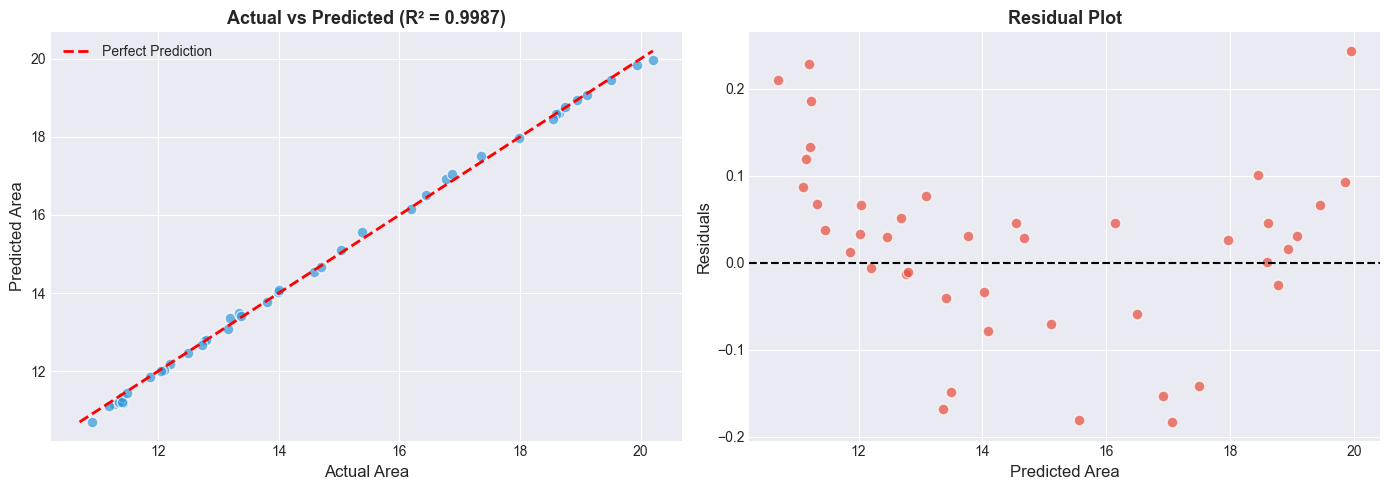

In [6]:
# Plot Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test_lr, y_pred_lr, alpha=0.7, color='#3498db', edgecolors='white', s=60)
min_val = min(y_test_lr.min(), y_pred_lr.min())
max_val = max(y_test_lr.max(), y_pred_lr.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Area', fontsize=12)
axes[0].set_ylabel('Predicted Area', fontsize=12)
axes[0].set_title(f'Actual vs Predicted (R² = {r2:.4f})', fontsize=13, fontweight='bold')
axes[0].legend()

# Residual plot
residuals = y_test_lr.values - y_pred_lr
axes[1].scatter(y_pred_lr, residuals, alpha=0.7, color='#e74c3c', edgecolors='white', s=60)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Area', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

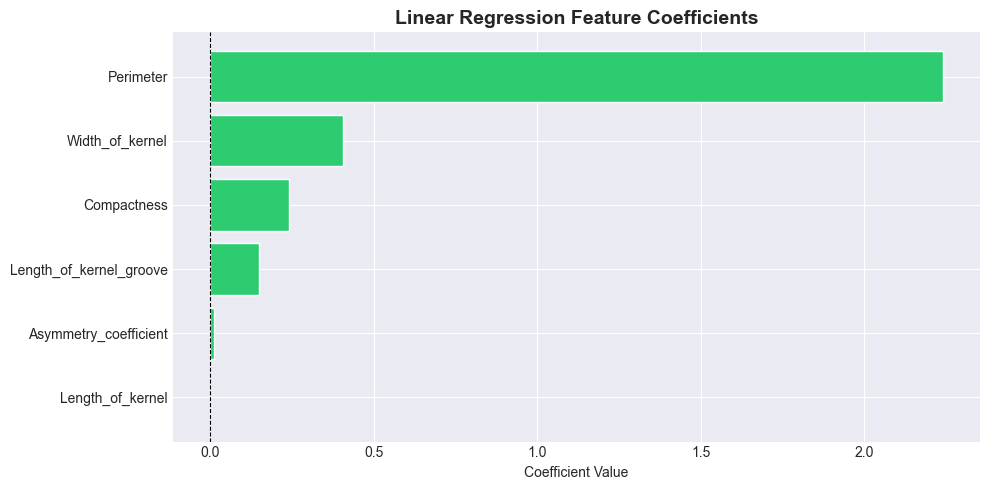

In [7]:
# Feature importance (coefficient magnitude)
fig, ax = plt.subplots(figsize=(10, 5))
coef_df_sorted = coef_df.sort_values('Coefficient')
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coef_df_sorted['Coefficient']]
ax.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Linear Regression Feature Coefficients', fontsize=14, fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

---
## Part B: Logistic Regression
**Task:** Classify wheat variety (Class 1, 2, 3)

### 6. Prepare Data for Logistic Regression

In [8]:
feature_cols = df.columns[:-1]
X = df[feature_cols]
y = df['Class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training: {X_train_scaled.shape[0]} samples")
print(f"Testing:  {X_test_scaled.shape[0]} samples")
print(f"\nClass distribution (train): {dict(pd.Series(y_train).value_counts().sort_index())}")
print(f"Class distribution (test):  {dict(pd.Series(y_test).value_counts().sort_index())}")

Training: 168 samples
Testing:  42 samples

Class distribution (train): {1: np.int64(56), 2: np.int64(56), 3: np.int64(56)}
Class distribution (test):  {1: np.int64(14), 2: np.int64(14), 3: np.int64(14)}


### 7. Train Logistic Regression Model

In [9]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model (Multinomial)")
print("=" * 50)
print(f"Classes: {log_model.classes_}")
print(f"Number of iterations: {log_model.n_iter_[0]}")

Logistic Regression Model (Multinomial)
Classes: [1 2 3]
Number of iterations: 18


### 8. Evaluate Logistic Regression

In [10]:
# Predictions
y_pred = log_model.predict(X_test_scaled)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Logistic Regression — Evaluation Metrics")
print("=" * 50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

Logistic Regression — Evaluation Metrics
Accuracy:  0.8810
Precision: 0.8995
Recall:    0.8810
F1 Score:  0.8731


In [11]:
# Classification report
class_names = ['Kama', 'Rosa', 'Canadian']
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

        Kama       1.00      0.64      0.78        14
        Rosa       0.88      1.00      0.93        14
    Canadian       0.82      1.00      0.90        14

    accuracy                           0.88        42
   macro avg       0.90      0.88      0.87        42
weighted avg       0.90      0.88      0.87        42



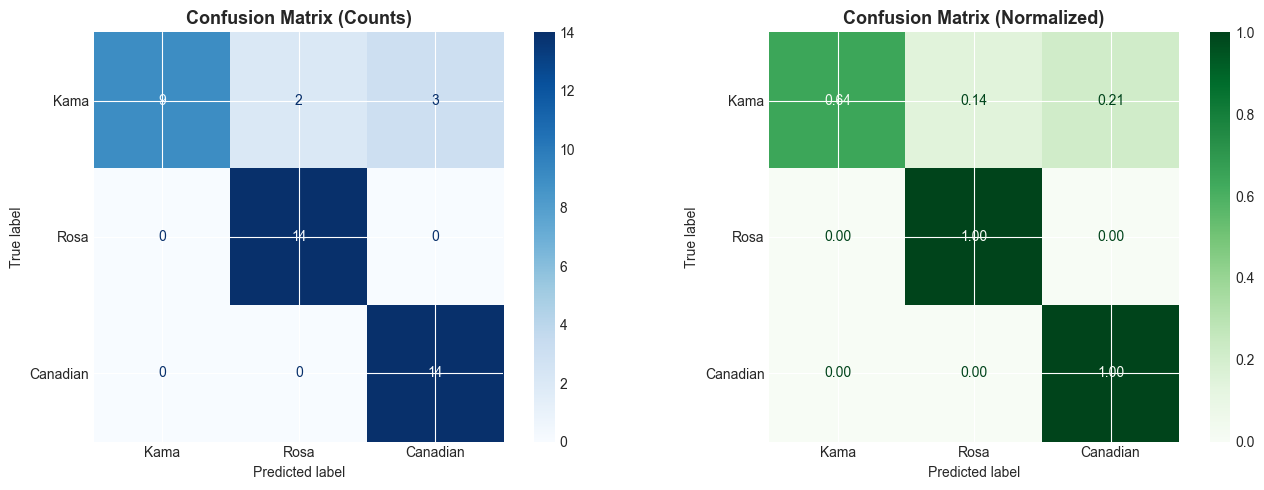

In [12]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Counts
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')

# Normalized
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp_norm.plot(cmap='Greens', ax=axes[1], values_format='.2f')
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

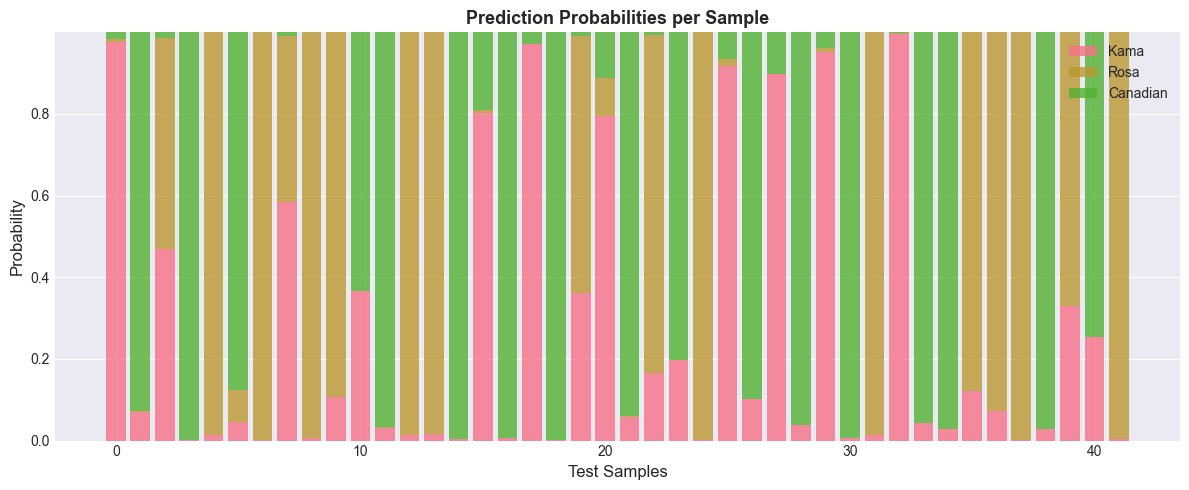

In [13]:
# Prediction probabilities
y_prob = log_model.predict_proba(X_test_scaled)

fig, ax = plt.subplots(figsize=(12, 5))
x_indices = np.arange(len(y_test))

for i, cls_name in enumerate(class_names):
    ax.bar(x_indices, y_prob[:, i], bottom=y_prob[:, :i].sum(axis=1),
           label=cls_name, alpha=0.8)

ax.set_xlabel('Test Samples', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Prediction Probabilities per Sample', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Comparison Summary

In [14]:
print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

print("\n📈 Linear Regression (Predicting Area):")
print(f"   R² Score: {r2:.4f}")
print(f"   RMSE:     {rmse:.4f}")
print(f"   MAE:      {mae:.4f}")

print("\n📊 Logistic Regression (Classifying Wheat Variety):")
print(f"   Accuracy:  {accuracy:.4f}")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1 Score:  {f1:.4f}")

MODEL COMPARISON SUMMARY

📈 Linear Regression (Predicting Area):
   R² Score: 0.9987
   RMSE:     0.1049
   MAE:      0.0815

📊 Logistic Regression (Classifying Wheat Variety):
   Accuracy:  0.8810
   Precision: 0.8995
   Recall:    0.8810
   F1 Score:  0.8731


## 10. Conclusion
In this lab, we:
- **Linear Regression**: Predicted wheat seed Area from other physical features. The model achieved high R², indicating strong linear relationships in the data.
- **Logistic Regression**: Classified wheat varieties with high accuracy using multinomial logistic regression. The confusion matrix and classification report show strong per-class performance.
- Both models benefit from feature scaling and demonstrate that the Seeds dataset has clear separable patterns.